# Imports:

In [83]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm
import numpy as np
import torch
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import StandardScaler

# Dataset:

For this project we use the Smell Pittsburgh dataset:

In [84]:
df_irregular = pd.read_csv("data/smell.csv")

# Loading external models:

This model is trained on data that includes stopwords and capital letters. So there is minimal extra preprocessing required to make embeddings from the textual data from the dataset.

In [85]:
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In order to visualize the data from both the TF-IDF and embeddings, we will use <i>Priciple Component Analasys</i> (PCA) to reduce the dimensions of the textual data.

In [86]:
pca = PCA(n_components=2)

# Text preprocessing

We first try to make an TF-IDF and plot these using PCA.

In [87]:
df_tfidf = df_irregular.copy()

We combine the three different column to create a richer context for better drift detection.

In [88]:
df_tfidf["combined"] = df_tfidf["smell description"].fillna("") + " " + df_tfidf["symptoms"].fillna("") + " " + df_tfidf["additional comments"].fillna("")

In [89]:
tfidf_comments = TfidfVectorizer(stop_words="english", max_features=500)

X_combined= tfidf_comments.fit_transform(df_tfidf["combined"].fillna(""))

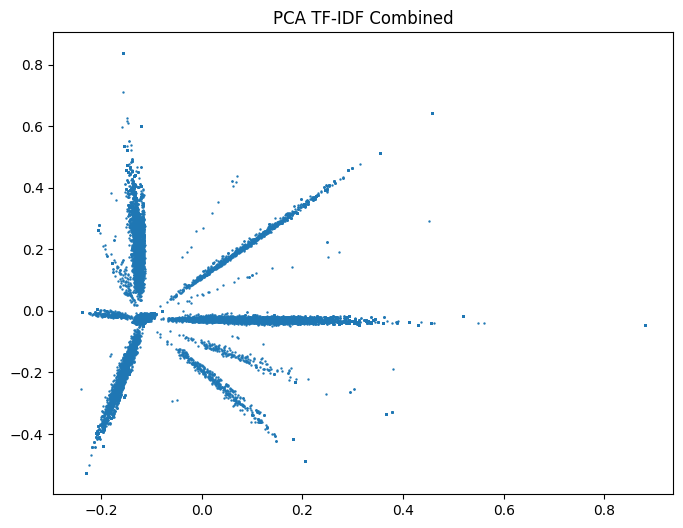

In [90]:
X_pca = PCA(n_components=2).fit_transform(X_combined.toarray())

plt.figure(figsize=(8,6))
plt.title("PCA TF-IDF Combined")
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=0.5)

In the plot above we can see a lot of spikes in the dataset. This is suboptimal for drift detection, since we see very little change in directions. Thus a TF-IDF isn't suited for our problem. A better strategy is to use embeddings.

# Regular Dataset

Creating the regular baseline dataset from the Smell Pittsburgh dataset.

Printing the head of the dataset to compare to the final result.

In [91]:
print(df_irregular.head())

   epoch time                 date & time  smell value  skewed latitude  \
0  1577836610  01/01/2020 00:56:50 +01:00            3        40.557110   
1  1577850486  01/01/2020 04:48:06 +01:00            3        40.423138   
2  1577852394  01/01/2020 05:19:54 +01:00            3        40.381115   
3  1577857682  01/01/2020 06:48:02 +01:00            3        40.307728   
4  1577883411  01/01/2020 13:56:51 +01:00            3        40.307781   

   skewed longitude  zipcode                                smell description  \
0        -80.059578    15237  Sulfur. Hydrogen Sulfide.  Clairton Coke Works.   
1        -79.920387    15217                                       Industrial   
2        -79.860985    15110                                      Industrial    
3        -79.860908    15037                                us steel clairton   
4        -79.860908    15037                               u s steel clairton   

                         symptoms  \
0  Sore throat and lungs.

Initiliaze the regular sampled dataset as a copy of the irregular dataset.

In [92]:
df_regular = df_irregular.copy()

Make the 'date & time' column the index of the new dataset. This is done in order to resample the data in the next step. The column is also made into a <i>datetime</i>, to ensure correct interpertation by pandas.

In [93]:
df_regular["date & time"] = pd.to_datetime(df_regular["date & time"], utc=True)
df_regular = df_regular.set_index("date & time").sort_index()

In [96]:
df_temp = df_irregular.copy()

## Adding the text data to the regular dataset

We first combine the data together as done with the TF-IDF, afterwards we resample the data to hourly. If there are more reports with text, all the text gets added into one cell.

In [97]:
df_temp["date & time"] = pd.to_datetime(df_temp["date & time"], utc=True)
df_temp = df_temp.set_index("date & time").sort_index()

df_temp["combined"] = (df_temp["smell description"].fillna("") + " " + df_temp["symptoms"].fillna("") + " " + df_temp["additional comments"].fillna(""))

In [98]:
embeddings = model.encode(df_temp["combined"].tolist())

In [99]:
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

df_temp["text_emb_1"] = embeddings_2d[:, 0]
df_temp["text_emb_2"] = embeddings_2d[:, 1]

In [103]:
df_regular = df_temp.resample("1h").agg(
    count=("smell value", "size"),
    mean_smell=("smell value", "mean"),
    latitude_mean=("skewed latitude", "mean"),
    latitude_std=("skewed latitude", "std"),
    longitude_mean=("skewed longitude", "mean"),
    longitude_std=("skewed longitude", "std"),
    combined=("combined", " ".join), 
    text_emb_1_mean=("text_emb_1", "mean"),
    text_emb_1_std=("text_emb_1", "std"),
    text_emb_2_mean=("text_emb_2", "mean"),
    text_emb_2_std=("text_emb_2", "std"),
    )

In [104]:
df_regular = df_regular.fillna(0)

In [105]:
print(df_regular.head)

<bound method NDFrame.head of                            count  mean_smell  latitude_mean  latitude_std  \
date & time                                                                 
2019-12-31 23:00:00+00:00      1         3.0      40.557110           0.0   
2020-01-01 00:00:00+00:00      0         0.0       0.000000           0.0   
2020-01-01 01:00:00+00:00      0         0.0       0.000000           0.0   
2020-01-01 02:00:00+00:00      0         0.0       0.000000           0.0   
2020-01-01 03:00:00+00:00      1         3.0      40.423138           0.0   
...                          ...         ...            ...           ...   
2025-12-31 15:00:00+00:00      0         0.0       0.000000           0.0   
2025-12-31 16:00:00+00:00      0         0.0       0.000000           0.0   
2025-12-31 17:00:00+00:00      0         0.0       0.000000           0.0   
2025-12-31 18:00:00+00:00      0         0.0       0.000000           0.0   
2025-12-31 19:00:00+00:00      1         5.0  

Saving the dataset as an .csv

In [ ]:
df_regular.to_csv("data/smell_regular.csv")

# Irregular dataset

In [187]:
df_irregular["date & time"] = pd.to_datetime(df_irregular["date & time"], utc=True)
df_irregular = df_irregular.set_index("date & time").sort_index()

In [190]:
df_irregular["combined"] = (df_irregular["smell description"].fillna("") + " " + df_irregular["symptoms"].fillna("") + " " + df_irregular["additional comments"].fillna(""))

In [191]:
embeddings = model.encode(df_irregular["combined"].tolist())

In [195]:
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

df_irregular["text_emb_1"] = embeddings_2d[:, 0]
df_irregular["text_emb_2"] = embeddings_2d[:, 1]

In [196]:
df_irregular = df_irregular.fillna(0)

In [197]:
print(df_irregular.head)

<bound method NDFrame.head of                            epoch time  smell value  skewed latitude  \
date & time                                                           
2019-12-31 23:56:50+00:00  1577836610            3        40.557110   
2020-01-01 03:48:06+00:00  1577850486            3        40.423138   
2020-01-01 04:19:54+00:00  1577852394            3        40.381115   
2020-01-01 05:48:02+00:00  1577857682            3        40.307728   
2020-01-01 12:56:51+00:00  1577883411            3        40.307781   
...                               ...          ...              ...   
2025-12-29 18:44:04+00:00  1767033844            3        40.501625   
2025-12-29 19:03:30+00:00  1767035010            2        40.480525   
2025-12-31 09:47:55+00:00  1767174475            1        40.484813   
2025-12-31 14:36:50+00:00  1767191810            1        40.424848   
2025-12-31 19:49:30+00:00  1767210570            5        40.396370   

                           skewed longitude  z

In [198]:
df_irregular.to_csv("data/smell_irregular.csv")

## Visualizing the data

Different plots of the data, based on location and comments a day:

In [106]:
print(df_irregular.columns)

Index(['epoch time', 'date & time', 'smell value', 'skewed latitude',
       'skewed longitude', 'zipcode', 'smell description', 'symptoms',
       'additional comments'],
      dtype='object')


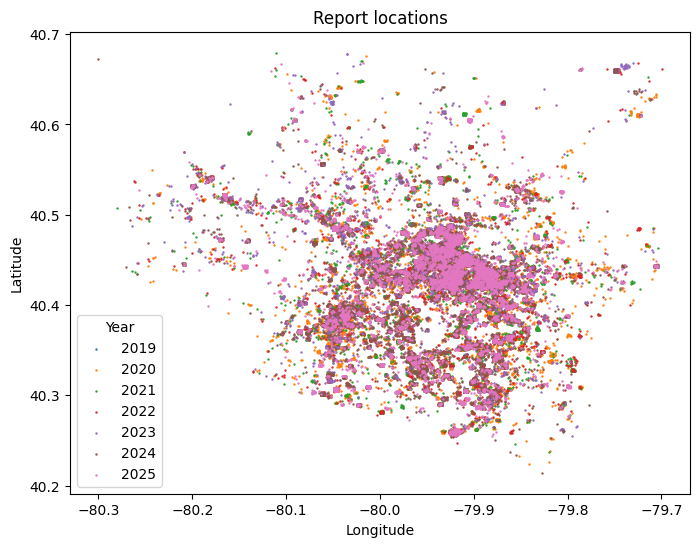

In [107]:
df_irregular["year"] = pd.to_datetime(df_irregular["date & time"], errors="coerce", utc=True)
df_irregular["year"] = df_irregular["year"].dt.year

plt.figure(figsize=(8,6))

for i in df_irregular["year"].dropna().unique():
    subset = df_irregular[df_irregular["year"] == i]
    
    plt.scatter(subset["skewed longitude"], subset["skewed latitude"], label=str(i), s=0.5)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Report locations")
plt.legend(title="Year")

plt.show()

# Implementing the MMD on the regular set

In [203]:
features_reg = [
    "count",
    "mean_smell",
    "latitude_mean",
    "longitude_mean",
    "latitude_std",
    "longitude_std",
    "text_emb_1_mean",
    "text_emb_1_std",
    "text_emb_2_mean",
    "text_emb_2_std"
]

In [207]:
features_ir = [
    "smell value",
    "skewed latitude",
    "skewed longitude",
    "text_emb_1",
    "text_emb_2",
]

In [208]:
X = df_regular[features_reg].values.astype(np.float32)

In [209]:
X = df_irregular[features_ir].values.astype(np.float32)

In [210]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [212]:
mask = df_regular["count"] > 0
X = X[mask.values]

IndexError: boolean index did not match indexed array along dimension 0; dimension is 75251 but corresponding boolean dimension is 52605

In [214]:
ref_end = 500

X_ref = X[:ref_end]

Implementation of the RBF kernel:

In [108]:
def rbf_kernel(x, y, sigma):
    diff = x[:, None, :] - y[None, :, :]
    dist = (diff ** 2).sum(dim=-1)
    return torch.exp(-dist / (2 * sigma ** 2))

Implementation of the MMD:

In [109]:
def mmd(x, y, sigma):
    return (rbf_kernel(x, x, sigma).mean() + rbf_kernel(y, y, sigma).mean() - 2 * rbf_kernel(x, y, sigma).mean())

In [165]:
def windows(X, window, step):
    results = []

    for i in range(0, len(X) - window + 1, step):
        results.append(X[i:i + window])

    return np.stack(results)

In [116]:
def summarize(windows):
    x = torch.tensor(windows).float()
    
    mean = x.mean(dim=1)
    std = x.std(dim=1)
    trend = x[:, -1] - x[:, 0]
    
    return torch.cat([mean, std, trend], dim=1)

In [119]:
def drift(X, ref_end=200, window=48, step=24, sigma=2.0):
    ref = X[:ref_end]
    ref_window = summarize(windows(ref, window, step))

    results = []

    for i in range(ref_end, len(X) - window, step):
        test = X[i:i + window * 2]
        test_window = summarize(windows(test, window, step))

        score = mmd(ref_window, test_window, sigma)

        results.append(score.item())

    return results

In [166]:
def median_heuristic(x):
    dists = torch.cdist(x, x, p=2)
    return torch.median(dists).item()

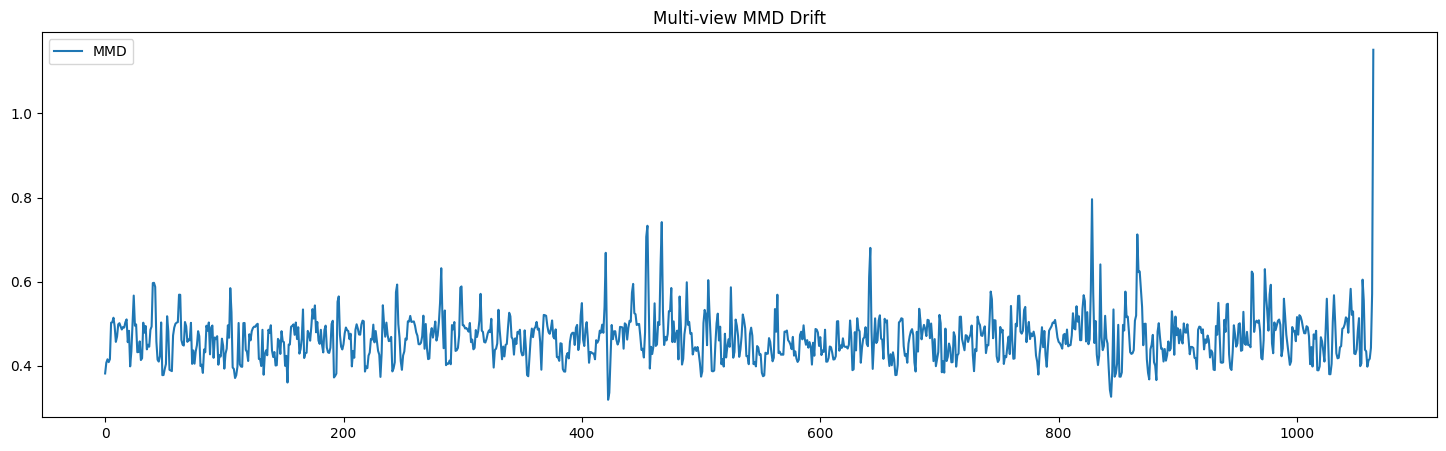

In [ ]:
results = drift(X)

plt.figure(figsize=(18, 5))
plt.plot(results, label="MMD")

plt.legend()
plt.title("Regular MMD")
plt.show()

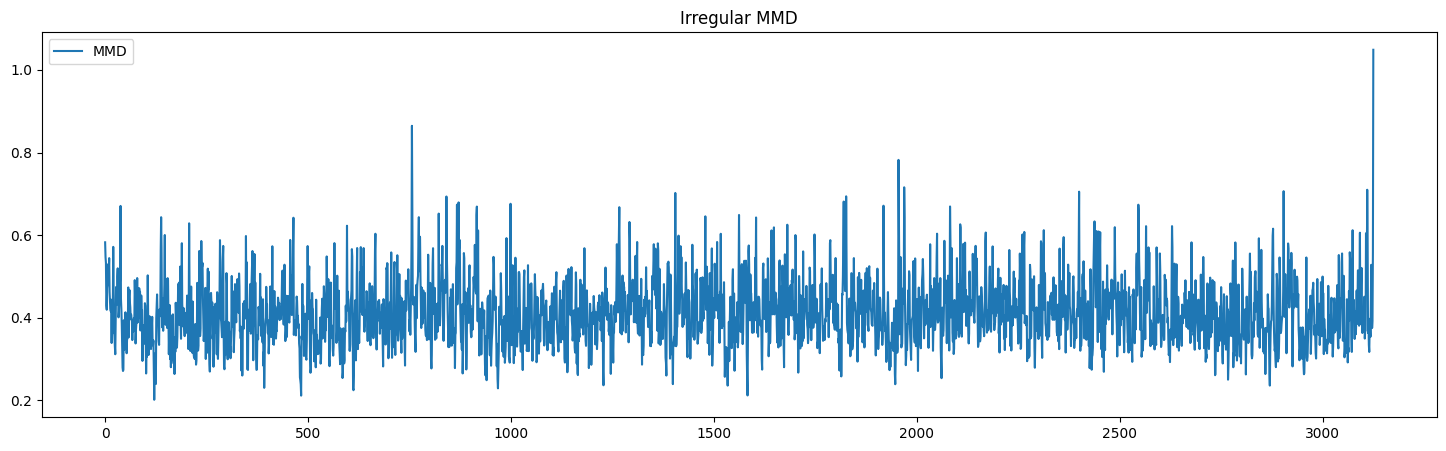

In [215]:
results = drift(X)

plt.figure(figsize=(18, 5))
plt.plot(results, label="MMD")

plt.legend()
plt.title("Irregular MMD")
plt.show()